In [0]:
# Cell 1 — Load all analysis results

results_base = "/Volumes/workspace/default/hmda_raw/delta/results"

df_q1        = spark.read.format("delta").load(f"{results_base}/q1_denial_rates")
df_q1_gap    = spark.read.format("delta").load(f"{results_base}/q1_disparity")
df_q2        = spark.read.format("delta").load(f"{results_base}/q2_rate_spread")
df_q2_gap    = spark.read.format("delta").load(f"{results_base}/q2_spread_disparity")
df_q3        = spark.read.format("delta").load(f"{results_base}/q3_lender_fairness")

# Convert to pandas for matplotlib
import pandas as pd
pd_q1        = df_q1.toPandas()
pd_q1_gap    = df_q1_gap.toPandas()
pd_q2        = df_q2.toPandas()
pd_q2_gap    = df_q2_gap.toPandas()
pd_q3        = df_q3.toPandas()

print("✅ All result tables loaded into pandas")
print(f"   Q1 denial rates : {len(pd_q1)} rows")
print(f"   Q1 disparity    : {len(pd_q1_gap)} rows")
print(f"   Q2 rate spread  : {len(pd_q2)} rows")
print(f"   Q2 gap          : {len(pd_q2_gap)} rows")
print(f"   Q3 lender       : {len(pd_q3)} rows")

✅ All result tables loaded into pandas
   Q1 denial rates : 25 rows
   Q1 disparity    : 20 rows
   Q2 rate spread  : 20 rows
   Q2 gap          : 4 rows
   Q3 lender       : 50 rows


In [0]:
import os
os.makedirs("/Volumes/workspace/default/hmda_raw/charts", exist_ok=True)
print("✅ Charts folder created")

✅ Charts folder created


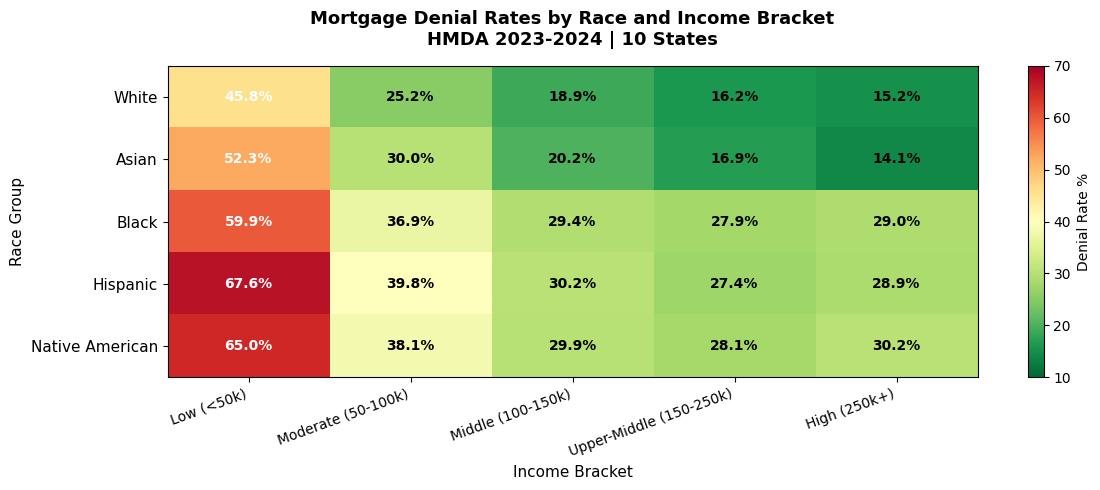

✅ Chart 1 saved


In [0]:
# Cell 2 — Chart 1: Denial Rate by Race and Income Bracket (FIXED)

import matplotlib.pyplot as plt
import numpy as np

# Create charts folder
import os
os.makedirs("/Volumes/workspace/default/hmda_raw/charts", exist_ok=True)

income_order = [
    "Low (<50k)", 
    "Moderate (50-100k)", 
    "Middle (100-150k)", 
    "Upper-Middle (150-250k)", 
    "High (250k+)"
]
race_order = ["White", "Asian", "Black", "Hispanic", "Native American"]

# Filter and pivot
df_filtered = pd_q1[
    pd_q1["race_group"].isin(race_order) & 
    pd_q1["income_bracket"].isin(income_order)
].copy()

# Force numeric
df_filtered["denial_rate_pct"] = pd.to_numeric(df_filtered["denial_rate_pct"], errors="coerce")

pivot = df_filtered.pivot_table(
    index="race_group",
    columns="income_bracket",
    values="denial_rate_pct",
    aggfunc="mean"
)
pivot = pivot.reindex(index=race_order, columns=income_order)

# Convert to float explicitly
data = pivot.values.astype(float)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(data, cmap="RdYlGn_r", aspect="auto", vmin=10, vmax=70)

ax.set_xticks(range(len(income_order)))
ax.set_yticks(range(len(race_order)))
ax.set_xticklabels(income_order, rotation=20, ha="right", fontsize=10)
ax.set_yticklabels(race_order, fontsize=11)

# Value annotations
for i in range(len(race_order)):
    for j in range(len(income_order)):
        val = data[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center",
                   fontsize=10, fontweight="bold",
                   color="white" if val > 45 else "black")

plt.colorbar(im, ax=ax, label="Denial Rate %")
ax.set_title(
    "Mortgage Denial Rates by Race and Income Bracket\nHMDA 2023-2024 | 10 States",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Income Bracket", fontsize=11)
ax.set_ylabel("Race Group", fontsize=11)

plt.tight_layout()
plt.savefig(
    "/Volumes/workspace/default/hmda_raw/charts/chart1_denial_heatmap.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Chart 1 saved")b

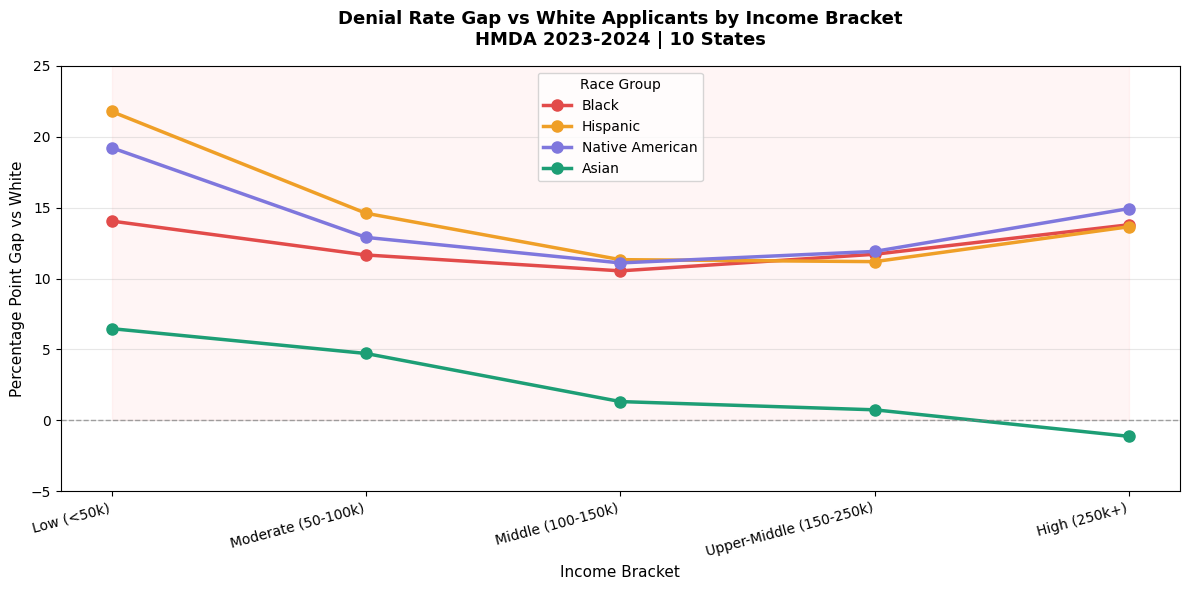

✅ Chart 2 saved


In [0]:
# Cell 3 — Chart 2: Denial Gap vs White borrowers across income brackets

import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(12, 6))

race_colors = {
    "Black":           "#E24B4A",
    "Hispanic":        "#EF9F27",
    "Native American": "#7F77DD",
    "Asian":           "#1D9E75"
}

income_order = [
    "Low (<50k)",
    "Moderate (50-100k)",
    "Middle (100-150k)",
    "Upper-Middle (150-250k)",
    "High (250k+)"
]

pd_q1_gap["gap_vs_white"] = pd.to_numeric(pd_q1_gap["gap_vs_white"], errors="coerce")

for race, color in race_colors.items():
    subset = pd_q1_gap[pd_q1_gap["race_group"] == race].copy()
    subset["income_bracket"] = pd.Categorical(
        subset["income_bracket"], categories=income_order, ordered=True
    )
    subset = subset.sort_values("income_bracket")
    ax.plot(
        subset["income_bracket"],
        subset["gap_vs_white"],
        marker="o", linewidth=2.5,
        markersize=8, label=race, color=color
    )

# Reference line
ax.axhline(y=0, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.fill_between(range(5), 0, 30, alpha=0.04, color="red")

ax.set_title(
    "Denial Rate Gap vs White Applicants by Income Bracket\nHMDA 2023-2024 | 10 States",
    fontsize=13, fontweight="bold", pad=15
)
ax.set_xlabel("Income Bracket", fontsize=11)
ax.set_ylabel("Percentage Point Gap vs White", fontsize=11)
ax.set_xticks(range(5))
ax.set_xticklabels(income_order, rotation=15, ha="right")
ax.legend(title="Race Group", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(-5, 25)

plt.tight_layout()
plt.savefig(
    "/Volumes/workspace/default/hmda_raw/charts/chart2_denial_gap.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Chart 2 saved")

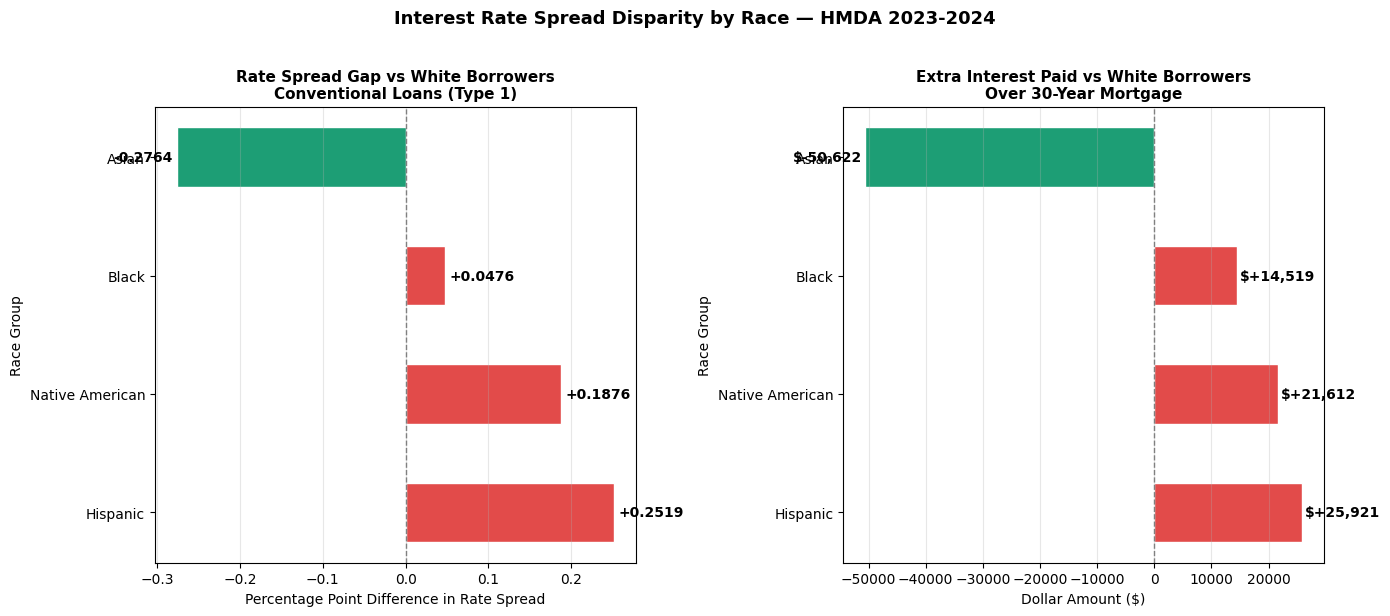

✅ Chart 3 saved


In [0]:
# Cell 4 — Chart 3: Rate spread gap vs White on conventional loans
# + Dollar impact over 30 years

import matplotlib.pyplot as plt
import numpy as np

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ── Left chart: Rate spread gap ───────────────────────────
races      = pd_q2_gap["race_group"].tolist()
gaps       = pd.to_numeric(pd_q2_gap["spread_gap"], errors="coerce").tolist()
colors     = ["#E24B4A" if g > 0 else "#1D9E75" for g in gaps]

bars = ax1.barh(races, gaps, color=colors, edgecolor="white", height=0.5)
ax1.axvline(x=0, color="gray", linestyle="--", linewidth=1)

for bar, gap in zip(bars, gaps):
    ax1.text(
        gap + (0.005 if gap >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{gap:+.4f}",
        va="center",
        ha="left" if gap >= 0 else "right",
        fontsize=10, fontweight="bold"
    )

ax1.set_title(
    "Rate Spread Gap vs White Borrowers\nConventional Loans (Type 1)",
    fontsize=11, fontweight="bold"
)
ax1.set_xlabel("Percentage Point Difference in Rate Spread", fontsize=10)
ax1.set_ylabel("Race Group", fontsize=10)
ax1.grid(axis="x", alpha=0.3)

# ── Right chart: Dollar impact over 30 years ──────────────
dollar_data = {
    "Hispanic":        25921,
    "Native American": 21612,
    "Black":           14519,
    "Asian":          -50622
}

race_labels = list(dollar_data.keys())
amounts     = list(dollar_data.values())
bar_colors  = ["#E24B4A" if a > 0 else "#1D9E75" for a in amounts]

bars2 = ax2.barh(race_labels, amounts, color=bar_colors, edgecolor="white", height=0.5)
ax2.axvline(x=0, color="gray", linestyle="--", linewidth=1)

for bar, amt in zip(bars2, amounts):
    ax2.text(
        amt + (500 if amt >= 0 else -500),
        bar.get_y() + bar.get_height() / 2,
        f"${amt:+,.0f}",
        va="center",
        ha="left" if amt >= 0 else "right",
        fontsize=10, fontweight="bold"
    )

ax2.set_title(
    "Extra Interest Paid vs White Borrowers\nOver 30-Year Mortgage",
    fontsize=11, fontweight="bold"
)
ax2.set_xlabel("Dollar Amount ($)", fontsize=10)
ax2.set_ylabel("Race Group", fontsize=10)
ax2.grid(axis="x", alpha=0.3)

fig.suptitle(
    "Interest Rate Spread Disparity by Race — HMDA 2023-2024",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(
    "/Volumes/workspace/default/hmda_raw/charts/chart3_rate_spread.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Chart 3 saved")b

/home/spark-c4c835c1-7c23-4f4a-80aa-7d/.ipykernel/2017/command-5122785757894710-3164506557:130: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/spark-c4c835c1-7c23-4f4a-80aa-7d/.ipykernel/2017/command-5122785757894710-3164506557:130: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/spark-c4c835c1-7c23-4f4a-80aa-7d/.ipykernel/2017/command-5122785757894710-3164506557:130: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/spark-c4c835c1-7c23-4f4a-80aa-7d/.ipykernel/2017/command-5122785757894710-3164506557:131: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(
/home/spark-c4c835c1-7c23-4f4a-80aa-7d/.ipykernel/2017/command-5122785757894710-3164506557:131: UserWarning: Glyph 128993 (\N{LARGE YELLOW CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(
/h

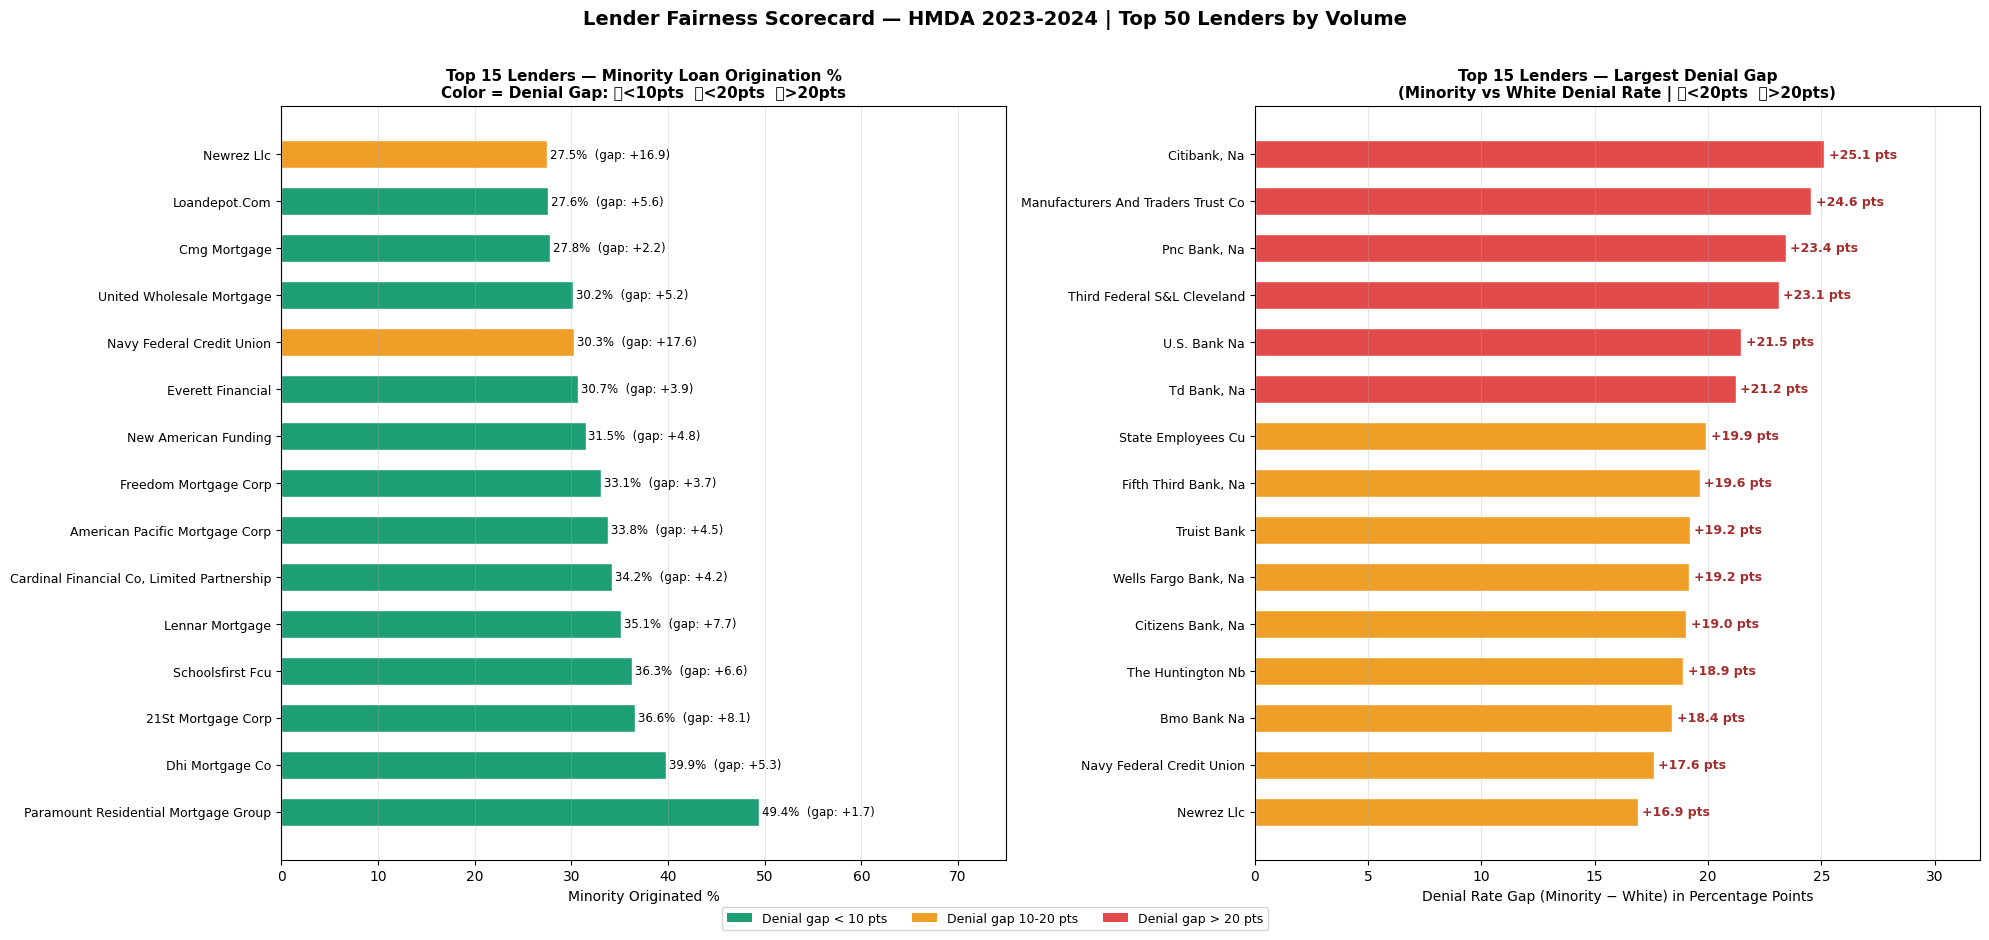

✅ Chart 4 rebuilt with real lender names


In [0]:
# Cell 5c — Rebuild Chart 4 with all real lender names

import matplotlib.pyplot as plt
import pandas as pd

# Clean up long names for display
def shorten(name):
    replacements = {
        "National Association": "NA",
        "National Bank": "NB",
        ", LLC": "",
        ", LTD.": "",
        ", INC.": "",
        ", Inc.": "",
        "CORPORATION": "Corp",
        "Corporation": "Corp",
        "COMPANY": "Co",
        "Company": "Co",
        "MORTGAGE": "Mortgage",
        "Federal Credit Union": "FCU",
        "Bank & Trust Company": "B&T",
        "Savings And Loan Association Of Cleveland": "S&L Cleveland",
        "Manufacturers and Traders Trust Company": "M&T Bank",
        "PARAMOUNT RESIDENTIAL MORTGAGE GROUP": "Paramount Residential",
        "SCHOOLSFIRST": "SchoolsFirst FCU",
        "STATE EMPLOYEES'": "State Employees CU",
    }
    for old, new in replacements.items():
        name = name.replace(old, new)
    return name.strip().title()

# Apply name mapping
pd_q3["lender_name"] = pd_q3["lei"].map(lei_name_map).apply(shorten)
pd_q3["minority_originated_pct"] = pd.to_numeric(
    pd_q3["minority_originated_pct"], errors="coerce"
)
pd_q3["denial_gap"] = pd.to_numeric(pd_q3["denial_gap"], errors="coerce")

# Sort
sorted_q3 = pd_q3.dropna(subset=["minority_originated_pct"]).sort_values(
    "minority_originated_pct", ascending=False
)
top15    = sorted_q3.head(15)
bottom15 = sorted_q3.tail(15).sort_values("minority_originated_pct")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# ── Left: Best minority serving ────────────────────────────
colors_top = [
    "#1D9E75" if g <= 10 
    else "#EF9F27" if g <= 20 
    else "#E24B4A"
    for g in top15["denial_gap"].fillna(0)
]

bars1 = ax1.barh(
    top15["lender_name"],
    top15["minority_originated_pct"],
    color=colors_top, edgecolor="white", height=0.6
)

for bar, val, gap in zip(bars1, top15["minority_originated_pct"], top15["denial_gap"].fillna(0)):
    ax1.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%  (gap: {gap:+.1f})",
        va="center", fontsize=8.5
    )

ax1.set_title(
    "Top 15 Lenders — Minority Loan Origination %\n"
    "Color = Denial Gap: 🟢<10pts  🟡<20pts  🔴>20pts",
    fontsize=11, fontweight="bold"
)
ax1.set_xlabel("Minority Originated %", fontsize=10)
ax1.set_xlim(0, 75)
ax1.grid(axis="x", alpha=0.3)
ax1.tick_params(axis="y", labelsize=9)

# ── Right: Worst denial gap ────────────────────────────────
risk = pd_q3.dropna(subset=["denial_gap"]).sort_values(
    "denial_gap", ascending=False
).head(15).sort_values("denial_gap")

bar_colors2 = [
    "#E24B4A" if g > 20 else "#EF9F27" 
    for g in risk["denial_gap"]
]

bars2 = ax2.barh(
    risk["lender_name"],
    risk["denial_gap"],
    color=bar_colors2, edgecolor="white", height=0.6
)

for bar, val in zip(bars2, risk["denial_gap"]):
    ax2.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f"+{val:.1f} pts",
        va="center", fontsize=9,
        color="#A32D2D", fontweight="bold"
    )

ax2.set_title(
    "Top 15 Lenders — Largest Denial Gap\n"
    "(Minority vs White Denial Rate | 🟡<20pts  🔴>20pts)",
    fontsize=11, fontweight="bold"
)
ax2.set_xlabel("Denial Rate Gap (Minority − White) in Percentage Points", fontsize=10)
ax2.set_xlim(0, 32)
ax2.grid(axis="x", alpha=0.3)
ax2.tick_params(axis="y", labelsize=9)

fig.suptitle(
    "Lender Fairness Scorecard — HMDA 2023-2024 | Top 50 Lenders by Volume",
    fontsize=14, fontweight="bold", y=1.01
)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1D9E75", label="Denial gap < 10 pts"),
    Patch(facecolor="#EF9F27", label="Denial gap 10-20 pts"),
    Patch(facecolor="#E24B4A", label="Denial gap > 20 pts"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(
    "/Volumes/workspace/default/hmda_raw/charts/chart4_lender_fairness.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Chart 4 rebuilt with real lender names")

/home/spark-c4c835c1-7c23-4f4a-80aa-7d/.ipykernel/2017/command-5122785757894713-2436332863:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  overall_denial = pd_q1.groupby("race_group").apply(


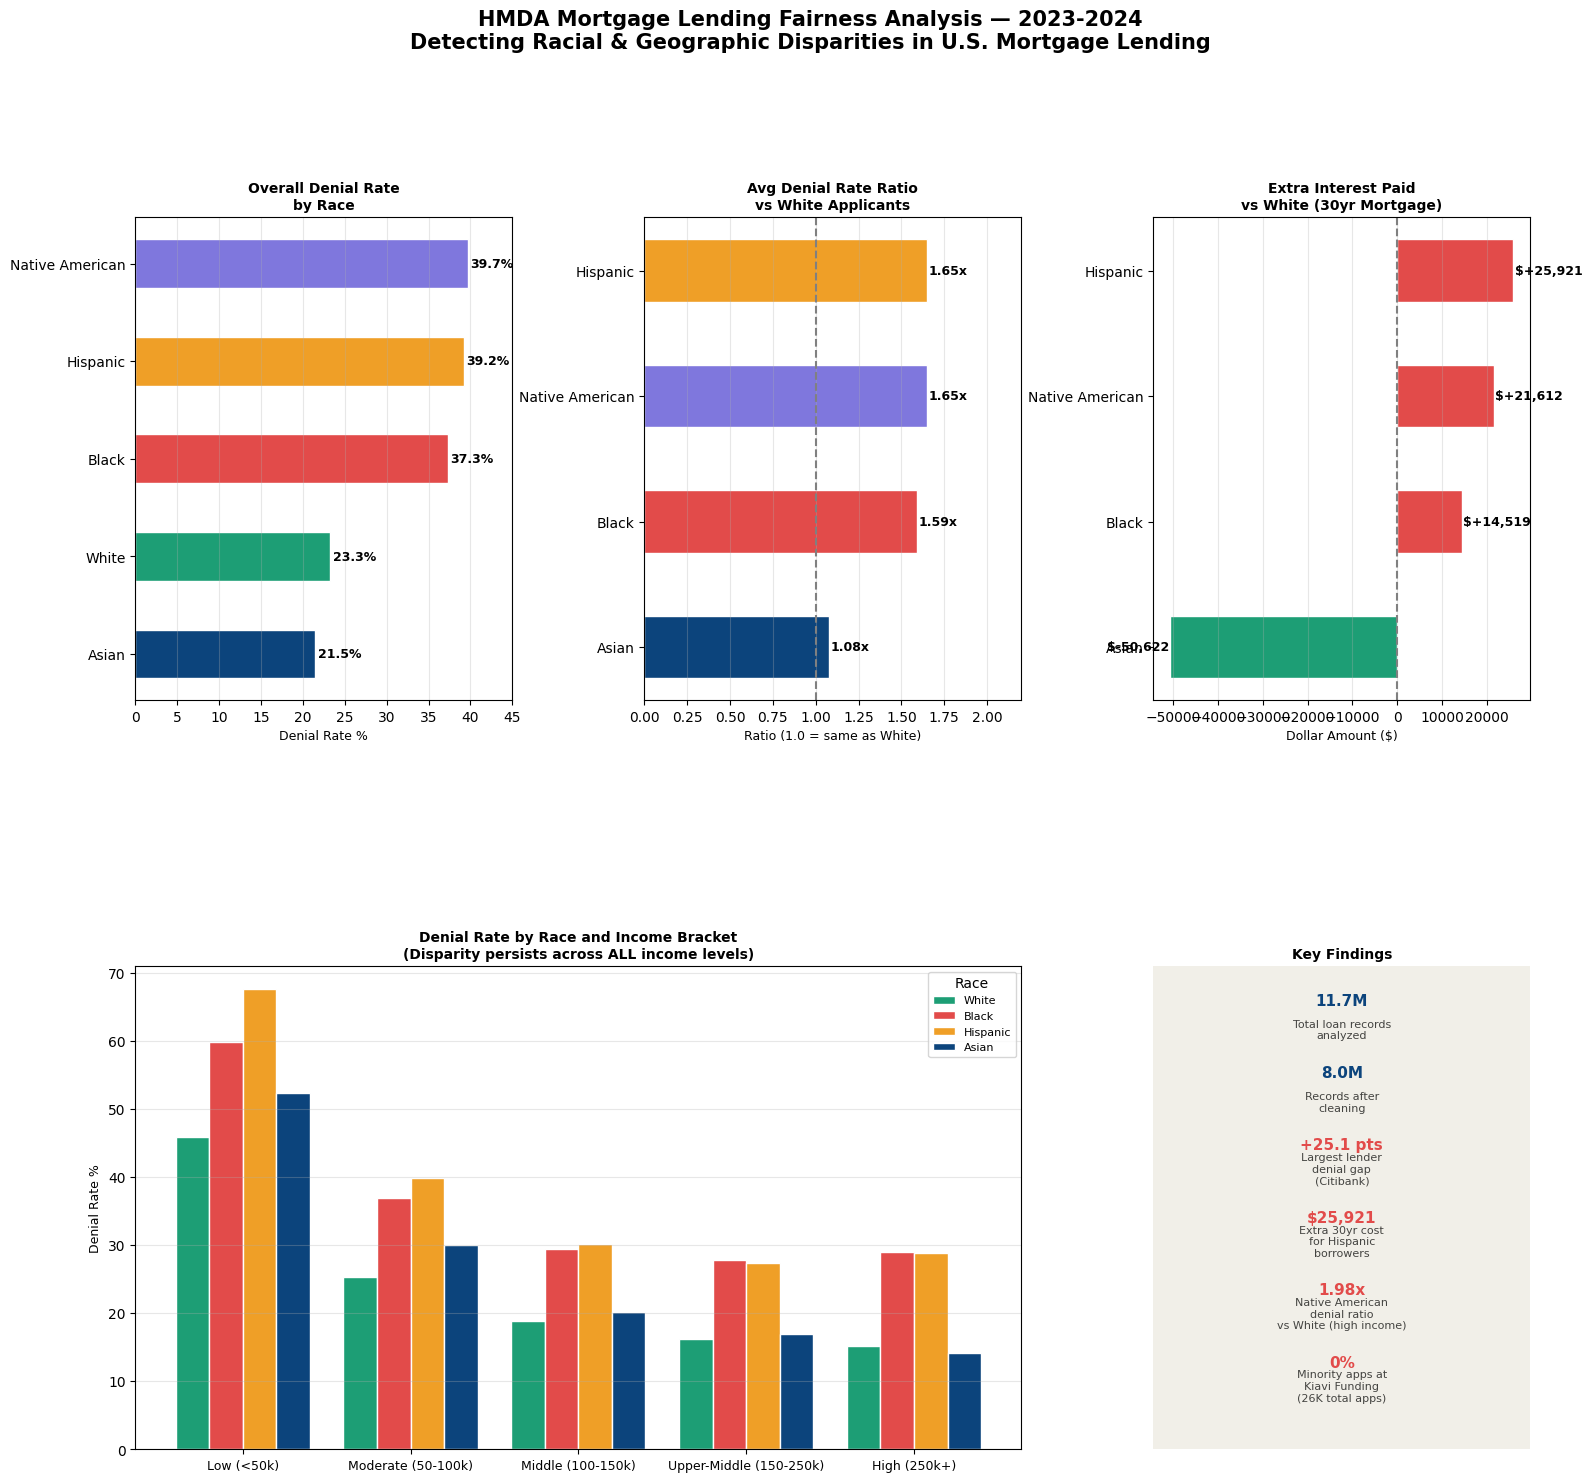

✅ Chart 5 — Executive Dashboard saved


In [0]:
# Cell 6 — Chart 5: Executive Summary Dashboard
# One chart that tells the whole story

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(18, 16))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, :2])
ax5 = fig.add_subplot(gs[1, 2])

# ── Panel 1: Overall denial rate by race ──────────────────
overall_denial = pd_q1.groupby("race_group").apply(
    lambda x: (x["total_denials"].sum() / x["total_applications"].sum() * 100)
).reset_index()
overall_denial.columns = ["race_group", "denial_rate"]
overall_denial = overall_denial[
    overall_denial["race_group"] != "Other/Unknown"
].sort_values("denial_rate", ascending=True)

race_colors_map = {
    "White":           "#1D9E75",
    "Asian":           "#0C447C",
    "Black":           "#E24B4A",
    "Hispanic":        "#EF9F27",
    "Native American": "#7F77DD"
}
colors = [race_colors_map.get(r, "#888780") for r in overall_denial["race_group"]]

bars = ax1.barh(overall_denial["race_group"], overall_denial["denial_rate"],
                color=colors, edgecolor="white", height=0.5)
for bar, val in zip(bars, overall_denial["denial_rate"]):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}%", va="center", fontsize=9, fontweight="bold")
ax1.set_title("Overall Denial Rate\nby Race", fontsize=10, fontweight="bold")
ax1.set_xlabel("Denial Rate %", fontsize=9)
ax1.set_xlim(0, 45)
ax1.grid(axis="x", alpha=0.3)

# ── Panel 2: Ratio vs White ────────────────────────────────
ratio_data = pd_q1_gap.groupby("race_group")["ratio_vs_white"].mean().reset_index()
ratio_data = ratio_data[ratio_data["race_group"] != "Other/Unknown"].sort_values(
    "ratio_vs_white", ascending=True
)
colors2 = [race_colors_map.get(r, "#888780") for r in ratio_data["race_group"]]

bars2 = ax2.barh(ratio_data["race_group"], ratio_data["ratio_vs_white"],
                 color=colors2, edgecolor="white", height=0.5)
ax2.axvline(x=1.0, color="gray", linestyle="--", linewidth=1.5)
for bar, val in zip(bars2, ratio_data["ratio_vs_white"]):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}x", va="center", fontsize=9, fontweight="bold")
ax2.set_title("Avg Denial Rate Ratio\nvs White Applicants", fontsize=10, fontweight="bold")
ax2.set_xlabel("Ratio (1.0 = same as White)", fontsize=9)
ax2.set_xlim(0, 2.2)
ax2.grid(axis="x", alpha=0.3)

# ── Panel 3: Extra $ paid over 30 years ───────────────────
dollar_impact = {
    "Hispanic":        25921,
    "Native American": 21612,
    "Black":           14519,
    "Asian":          -50622
}
dl = pd.DataFrame(list(dollar_impact.items()), columns=["race", "extra"])
dl = dl.sort_values("extra", ascending=True)
colors3 = ["#1D9E75" if v < 0 else "#E24B4A" for v in dl["extra"]]

bars3 = ax3.barh(dl["race"], dl["extra"], color=colors3, edgecolor="white", height=0.5)
ax3.axvline(x=0, color="gray", linestyle="--", linewidth=1.5)
for bar, val in zip(bars3, dl["extra"]):
    ax3.text(
        bar.get_width() + (300 if val >= 0 else -300),
        bar.get_y() + bar.get_height()/2,
        f"${val:+,.0f}",
        va="center", ha="left" if val >= 0 else "right",
        fontsize=9, fontweight="bold"
    )
ax3.set_title("Extra Interest Paid\nvs White (30yr Mortgage)", fontsize=10, fontweight="bold")
ax3.set_xlabel("Dollar Amount ($)", fontsize=9)
ax3.grid(axis="x", alpha=0.3)

# ── Panel 4: Denial rate by race + income (grouped bar) ───
income_order = [
    "Low (<50k)", "Moderate (50-100k)", "Middle (100-150k)",
    "Upper-Middle (150-250k)", "High (250k+)"
]
races_plot  = ["White", "Black", "Hispanic", "Asian"]
x           = np.arange(len(income_order))
width       = 0.2

for i, race in enumerate(races_plot):
    subset = pd_q1[
        (pd_q1["race_group"] == race) &
        (pd_q1["income_bracket"].isin(income_order))
    ].copy()
    subset["income_bracket"] = pd.Categorical(
        subset["income_bracket"], categories=income_order, ordered=True
    )
    subset = subset.sort_values("income_bracket")
    vals = pd.to_numeric(subset["denial_rate_pct"], errors="coerce").tolist()
    ax4.bar(x + i * width, vals, width, label=race,
            color=race_colors_map.get(race, "#888780"), edgecolor="white")

ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(income_order, fontsize=9)
ax4.set_title(
    "Denial Rate by Race and Income Bracket\n(Disparity persists across ALL income levels)",
    fontsize=10, fontweight="bold"
)
ax4.set_ylabel("Denial Rate %", fontsize=9)
ax4.legend(title="Race", fontsize=8)
ax4.grid(axis="y", alpha=0.3)

# ── Panel 5: Key stats callout ─────────────────────────────
ax5.axis("off")
stats = [
    ("11.7M",     "Total loan records\nanalyzed"),
    ("8.0M",      "Records after\ncleaning"),
    ("+25.1 pts", "Largest lender\ndenial gap\n(Citibank)"),
    ("$25,921",   "Extra 30yr cost\nfor Hispanic\nborrowers"),
    ("1.98x",     "Native American\ndenial ratio\nvs White (high income)"),
    ("0%",        "Minority apps at\nKiavi Funding\n(26K total apps)"),
]

y_pos = 0.92
for val, label in stats:
    ax5.text(0.5, y_pos, val, transform=ax5.transAxes,
             fontsize=11, fontweight="bold", ha="center",
             color="#E24B4A" if val.startswith("+") or val.startswith("$") or
             val in ["1.98x", "0%"] else "#0C447C")
    ax5.text(0.5, y_pos - 0.07, label, transform=ax5.transAxes,
             fontsize=8, ha="center", color="#444441")
    y_pos -= 0.15

ax5.set_title("Key Findings", fontsize=10, fontweight="bold")
ax5.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax5.transAxes,
                              fill=True, facecolor="#F1EFE8", zorder=-1))

fig.suptitle(
    "HMDA Mortgage Lending Fairness Analysis — 2023-2024\n"
    "Detecting Racial & Geographic Disparities in U.S. Mortgage Lending",
    fontsize=15, fontweight="bold", y=1.01
)

plt.savefig(
    "/Volumes/workspace/default/hmda_raw/charts/chart5_executive_dashboard.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Chart 5 — Executive Dashboard saved")

In [0]:
# Cell 1 — Load all results
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

results_base = "/Volumes/workspace/default/hmda_raw/delta/results"

pd_q4_deserts = spark.read.format("delta") \
    .load(f"{results_base}/q4_credit_deserts").toPandas()
pd_q4_county  = spark.read.format("delta") \
    .load(f"{results_base}/q4_county").toPandas()
pd_q5_cycle   = spark.read.format("delta") \
    .load(f"{results_base}/q5_rate_cycle").toPandas()
pd_q5_yoy     = spark.read.format("delta") \
    .load(f"{results_base}/q5_yoy").toPandas()

print("✅ All results loaded")
print(f"   Q4 credit deserts : {len(pd_q4_deserts)} tracts")
print(f"   Q4 county         : {len(pd_q4_county)} counties")
print(f"   Q5 rate cycle     : {len(pd_q5_cycle)} rows")
print(f"   Q5 YoY            : {len(pd_q5_yoy)} rows")

✅ All results loaded
   Q4 credit deserts : 23794 tracts
   Q4 county         : 1054 counties
   Q5 rate cycle     : 50 rows
   Q5 YoY            : 5 rows


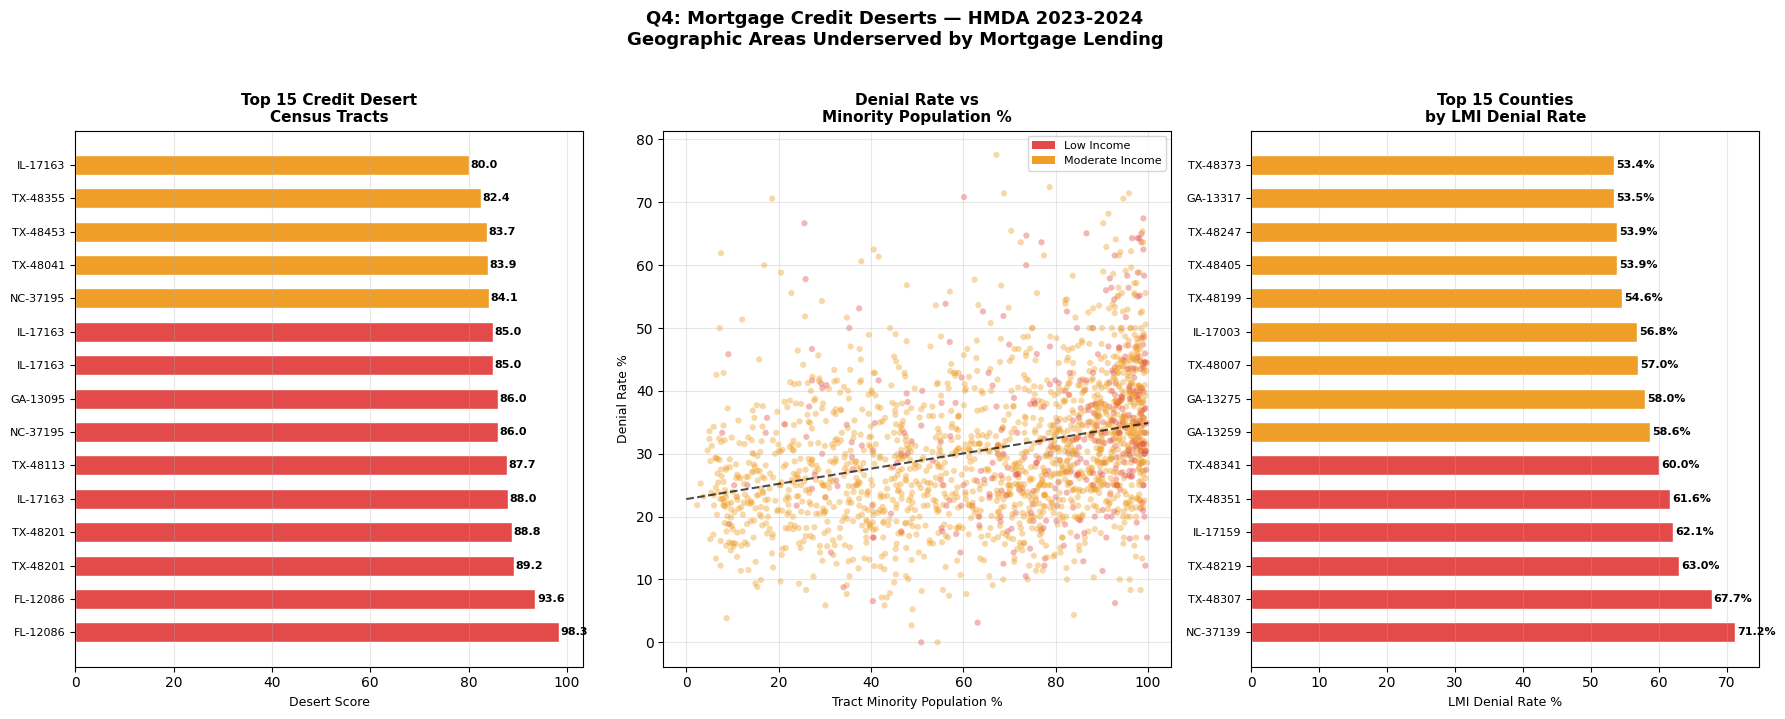

✅ Chart 6 saved


In [0]:
# Cell 2 — Chart 6: Q4 Credit Desert Analysis

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd_q4_deserts["desert_score"] = pd.to_numeric(
    pd_q4_deserts["desert_score"], errors="coerce"
)
pd_q4_deserts["denial_rate_pct"] = pd.to_numeric(
    pd_q4_deserts["denial_rate_pct"], errors="coerce"
)
pd_q4_deserts["tract_minority_population_percent"] = pd.to_numeric(
    pd_q4_deserts["tract_minority_population_percent"], errors="coerce"
)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

# ── Panel 1: Top 15 worst census tracts by desert score ───
top15_deserts = pd_q4_deserts.nlargest(15, "desert_score")

colors = ["#E24B4A" if s >= 85 
          else "#EF9F27" if s >= 75 
          else "#1D9E75" 
          for s in top15_deserts["desert_score"]]

bars = axes[0].barh(
    range(len(top15_deserts)),
    top15_deserts["desert_score"],
    color=colors, edgecolor="white", height=0.6
)

# Label with state + county
labels = [
    f"{row.state_code}-{row.county_code[:5]}"
    for _, row in top15_deserts.iterrows()
]
axes[0].set_yticks(range(len(top15_deserts)))
axes[0].set_yticklabels(labels, fontsize=8)
axes[0].set_title(
    "Top 15 Credit Desert\nCensus Tracts",
    fontsize=11, fontweight="bold"
)
axes[0].set_xlabel("Desert Score", fontsize=9)
axes[0].grid(axis="x", alpha=0.3)

for bar, val in zip(bars, top15_deserts["desert_score"]):
    axes[0].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}",
        va="center", fontsize=8, fontweight="bold"
    )

# ── Panel 2: Denial rate vs Minority % (scatter) ──────────
sample = pd_q4_deserts.sample(min(2000, len(pd_q4_deserts)))
sample["denial_rate_pct"] = pd.to_numeric(
    sample["denial_rate_pct"], errors="coerce"
)
sample["tract_minority_population_percent"] = pd.to_numeric(
    sample["tract_minority_population_percent"], errors="coerce"
)

scatter_colors = sample["tract_income_category"].map({
    "Low Income":      "#E24B4A",
    "Moderate Income": "#EF9F27"
})

axes[1].scatter(
    sample["tract_minority_population_percent"],
    sample["denial_rate_pct"],
    c=scatter_colors,
    alpha=0.4, s=20, edgecolors="none"
)

# Trend line
valid = sample.dropna(
    subset=["tract_minority_population_percent", "denial_rate_pct"]
)
z = np.polyfit(
    valid["tract_minority_population_percent"],
    valid["denial_rate_pct"], 1
)
p = np.poly1d(z)
x_line = np.linspace(0, 100, 100)
axes[1].plot(x_line, p(x_line), "k--", linewidth=1.5, alpha=0.7)

axes[1].set_title(
    "Denial Rate vs\nMinority Population %",
    fontsize=11, fontweight="bold"
)
axes[1].set_xlabel("Tract Minority Population %", fontsize=9)
axes[1].set_ylabel("Denial Rate %", fontsize=9)
axes[1].grid(alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#E24B4A", label="Low Income"),
    Patch(facecolor="#EF9F27", label="Moderate Income"),
]
axes[1].legend(handles=legend_elements, fontsize=8)

# ── Panel 3: Top 15 counties by LMI denial rate ───────────
pd_q4_county["lmi_denial_rate"] = pd.to_numeric(
    pd_q4_county["lmi_denial_rate"], errors="coerce"
)
top15_counties = pd_q4_county.dropna(
    subset=["lmi_denial_rate"]
).nlargest(15, "lmi_denial_rate")

county_colors = ["#E24B4A" if r >= 60 
                 else "#EF9F27" if r >= 50 
                 else "#1D9E75" 
                 for r in top15_counties["lmi_denial_rate"]]

bars3 = axes[2].barh(
    range(len(top15_counties)),
    top15_counties["lmi_denial_rate"],
    color=county_colors, edgecolor="white", height=0.6
)

county_labels = [
    f"{row.state_code}-{row.county_code}"
    for _, row in top15_counties.iterrows()
]
axes[2].set_yticks(range(len(top15_counties)))
axes[2].set_yticklabels(county_labels, fontsize=8)
axes[2].set_title(
    "Top 15 Counties\nby LMI Denial Rate",
    fontsize=11, fontweight="bold"
)
axes[2].set_xlabel("LMI Denial Rate %", fontsize=9)
axes[2].grid(axis="x", alpha=0.3)

for bar, val in zip(bars3, top15_counties["lmi_denial_rate"]):
    axes[2].text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", fontsize=8, fontweight="bold"
    )

fig.suptitle(
    "Q4: Mortgage Credit Deserts — HMDA 2023-2024\n"
    "Geographic Areas Underserved by Mortgage Lending",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(
    "/Volumes/workspace/default/hmda_raw/charts/chart6_credit_deserts.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Chart 6 saved")

/home/spark-5556cc0a-1245-4a63-8747-d8/.ipykernel/2026/command-5254854966800723-3729635087:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(race_order, rotation=15, ha="right", fontsize=9)
/home/spark-5556cc0a-1245-4a63-8747-d8/.ipykernel/2026/command-5254854966800723-3729635087:110: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(race_order, rotation=15, ha="right", fontsize=9)


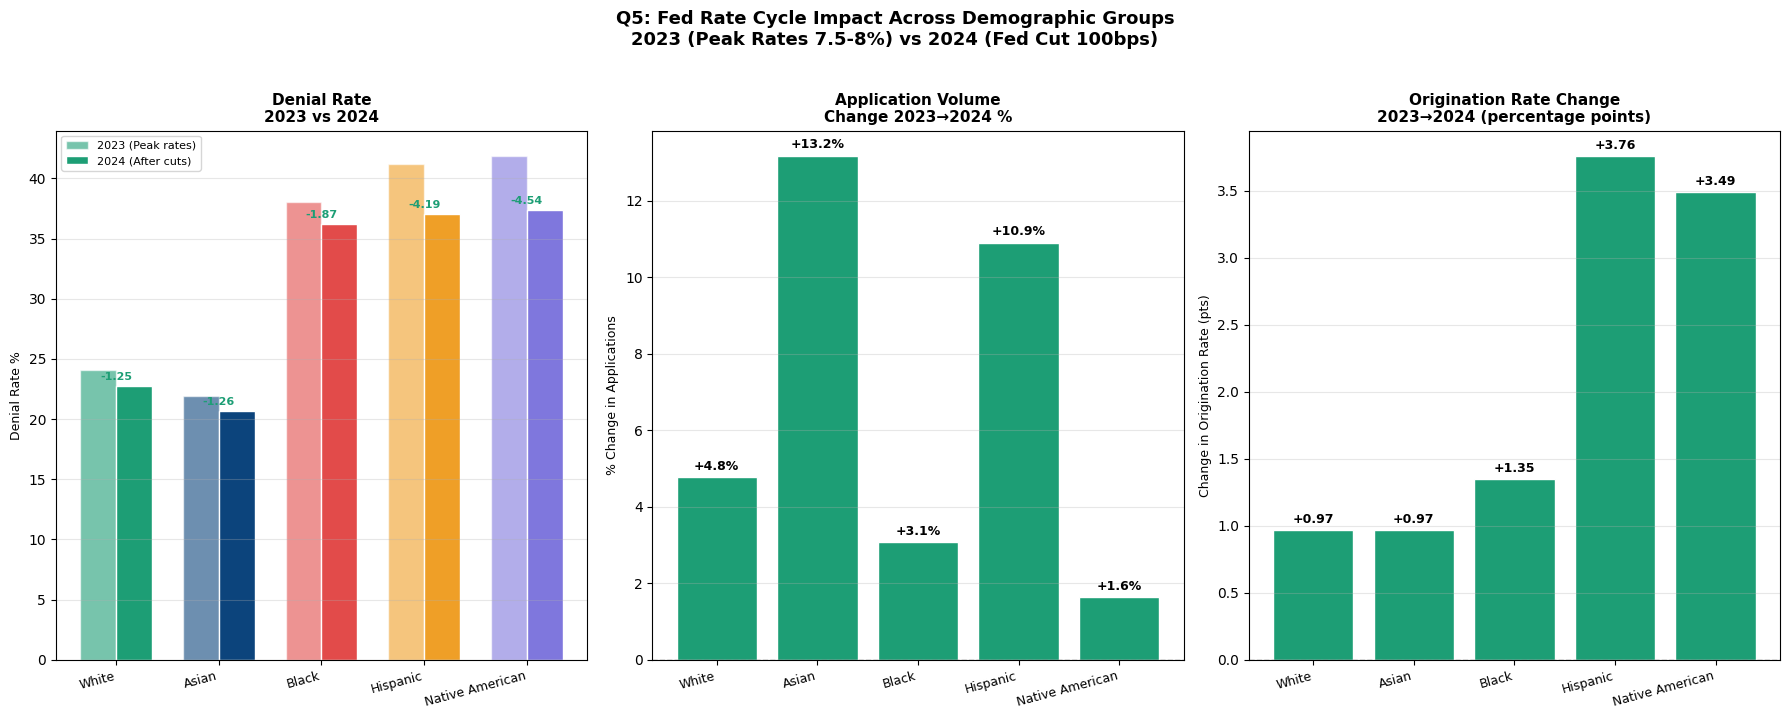

✅ Chart 7 saved


In [0]:
# Cell 3 — Chart 7: Fed Rate Cycle Impact

fig, axes = plt.subplots(1, 3, figsize=(18, 7))

race_colors = {
    "White":           "#1D9E75",
    "Asian":           "#0C447C",
    "Black":           "#E24B4A",
    "Hispanic":        "#EF9F27",
    "Native American": "#7F77DD"
}

race_order = ["White", "Asian", "Black", "Hispanic", "Native American"]

# ── Panel 1: Denial rate 2023 vs 2024 by race ─────────────
pd_q5_yoy["denial_2023"] = pd.to_numeric(pd_q5_yoy["denial_2023"], errors="coerce")
pd_q5_yoy["denial_2024"] = pd.to_numeric(pd_q5_yoy["denial_2024"], errors="coerce")
pd_q5_yoy["denial_rate_change"] = pd.to_numeric(pd_q5_yoy["denial_rate_change"], errors="coerce")
pd_q5_yoy["app_volume_change_pct"] = pd.to_numeric(pd_q5_yoy["app_volume_change_pct"], errors="coerce")
pd_q5_yoy["orig_rate_change"] = pd.to_numeric(pd_q5_yoy["orig_rate_change"], errors="coerce")

x = np.arange(len(race_order))
width = 0.35

yoy_sorted = pd_q5_yoy.set_index("race_group").reindex(race_order)

bars_2023 = axes[0].bar(
    x - width/2,
    yoy_sorted["denial_2023"],
    width, label="2023 (Peak rates)",
    color=[race_colors[r] for r in race_order],
    alpha=0.6, edgecolor="white"
)
bars_2024 = axes[0].bar(
    x + width/2,
    yoy_sorted["denial_2024"],
    width, label="2024 (After cuts)",
    color=[race_colors[r] for r in race_order],
    alpha=1.0, edgecolor="white"
)

axes[0].set_xticks(x)
axes[0].set_xticklabels(race_order, rotation=15, ha="right", fontsize=9)
axes[0].set_title(
    "Denial Rate\n2023 vs 2024",
    fontsize=11, fontweight="bold"
)
axes[0].set_ylabel("Denial Rate %", fontsize=9)
axes[0].legend(fontsize=8)
axes[0].grid(axis="y", alpha=0.3)

# Add change labels
for i, race in enumerate(race_order):
    change = yoy_sorted.loc[race, "denial_rate_change"]
    color  = "#1D9E75" if change < 0 else "#E24B4A"
    axes[0].text(
        i, yoy_sorted.loc[race, "denial_2024"] + 0.5,
        f"{change:+.2f}",
        ha="center", fontsize=8,
        fontweight="bold", color=color
    )

# ── Panel 2: Application volume change ────────────────────
vol_colors = [
    "#1D9E75" if v > 0 else "#E24B4A"
    for v in yoy_sorted["app_volume_change_pct"]
]

bars2 = axes[1].bar(
    race_order,
    yoy_sorted["app_volume_change_pct"],
    color=vol_colors, edgecolor="white"
)

axes[1].axhline(y=0, color="gray", linestyle="--", linewidth=1)
axes[1].set_title(
    "Application Volume\nChange 2023→2024 %",
    fontsize=11, fontweight="bold"
)
axes[1].set_ylabel("% Change in Applications", fontsize=9)
axes[1].set_xticklabels(race_order, rotation=15, ha="right", fontsize=9)
axes[1].grid(axis="y", alpha=0.3)

for bar, val in zip(bars2, yoy_sorted["app_volume_change_pct"]):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        f"{val:+.1f}%",
        ha="center", fontsize=9, fontweight="bold"
    )

# ── Panel 3: Origination rate change ──────────────────────
orig_colors = [
    "#1D9E75" if v > 0 else "#E24B4A"
    for v in yoy_sorted["orig_rate_change"]
]

bars3 = axes[2].bar(
    race_order,
    yoy_sorted["orig_rate_change"],
    color=orig_colors, edgecolor="white"
)

axes[2].axhline(y=0, color="gray", linestyle="--", linewidth=1)
axes[2].set_title(
    "Origination Rate Change\n2023→2024 (percentage points)",
    fontsize=11, fontweight="bold"
)
axes[2].set_ylabel("Change in Origination Rate (pts)", fontsize=9)
axes[2].set_xticklabels(race_order, rotation=15, ha="right", fontsize=9)
axes[2].grid(axis="y", alpha=0.3)

for bar, val in zip(bars3, yoy_sorted["orig_rate_change"]):
    axes[2].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"{val:+.2f}",
        ha="center", fontsize=9, fontweight="bold"
    )

fig.suptitle(
    "Q5: Fed Rate Cycle Impact Across Demographic Groups\n"
    "2023 (Peak Rates 7.5-8%) vs 2024 (Fed Cut 100bps)",
    fontsize=13, fontweight="bold", y=1.02
)

plt.tight_layout()
plt.savefig(
    "/Volumes/workspace/default/hmda_raw/charts/chart7_fed_rate_cycle.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("✅ Chart 7 saved")

In [0]:
# Cell 7b — Back up charts to S3 using boto3

import boto3
import os

# You'll need to update these credentials from your AWS lab
# cat ~/.aws/credentials in Cloud9 to get fresh ones
s3 = boto3.client(
    "s3",
    region_name="us-east-1",
    aws_access_key_id="YOUR_ACCESS_KEY",
    aws_secret_access_key="YOUR_SECRET_KEY",
    aws_session_token="YOUR_SESSION_TOKEN"
)

bucket = "hmda-datalake-313607939153"
charts_path = "/Volumes/workspace/default/hmda_raw/charts"

charts = [
    "chart1_denial_heatmap.png",
    "chart2_denial_gap.png",
    "chart3_rate_spread.png",
    "chart4_lender_fairness.png",
    "chart5_executive_dashboard.png"
]

for chart in charts:
    local = f"{charts_path}/{chart}"
    s3_key = f"charts/{chart}"
    try:
        s3.upload_file(local, bucket, s3_key)
        print(f"✅ {chart} → s3://{bucket}/{s3_key}")
    except Exception as e:
        print(f"❌ {chart} failed: {e}")

print("\n✅ All charts uploaded to S3")

❌ chart1_denial_heatmap.png failed: Failed to upload /Volumes/workspace/default/hmda_raw/charts/chart1_denial_heatmap.png to hmda-datalake-313607939153/charts/chart1_denial_heatmap.png: An error occurred (InvalidAccessKeyId) when calling the PutObject operation: The AWS Access Key Id you provided does not exist in our records.
❌ chart2_denial_gap.png failed: Failed to upload /Volumes/workspace/default/hmda_raw/charts/chart2_denial_gap.png to hmda-datalake-313607939153/charts/chart2_denial_gap.png: An error occurred (InvalidAccessKeyId) when calling the PutObject operation: The AWS Access Key Id you provided does not exist in our records.
❌ chart3_rate_spread.png failed: Failed to upload /Volumes/workspace/default/hmda_raw/charts/chart3_rate_spread.png to hmda-datalake-313607939153/charts/chart3_rate_spread.png: An error occurred (InvalidAccessKeyId) when calling the PutObject operation: The AWS Access Key Id you provided does not exist in our records.
❌ chart4_lender_fairness.png faile

In [0]:
# Cell 5b — Look up ALL 50 lender names from GLEIF API

import requests
import time

lei_list = pd_q3["lei"].tolist()
lei_name_map = {}

print(f"Looking up {len(lei_list)} lenders...")
print("-" * 60)

for i, lei in enumerate(lei_list):
    try:
        url = f"https://api.gleif.org/api/v1/lei-records/{lei}"
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            name = r.json()["data"]["attributes"]["entity"]["legalName"]["name"]
        else:
            name = f"Unknown ({lei[:8]})"
    except Exception as e:
        name = f"Error ({lei[:8]})"
    
    lei_name_map[lei] = name
    print(f"  {i+1:02d}. {lei} → {name}")
    time.sleep(0.3)  # be polite to the API

print("\n✅ All lender names retrieved!")

Looking up 50 lenders...
------------------------------------------------------------
  01. 254900ZFWS2106HWPH46 → PARAMOUNT RESIDENTIAL MORTGAGE GROUP, INC.
  02. 5493001SXWZ4OFP8Z903 → DHI MORTGAGE COMPANY, LTD.
  03. 549300XQVJ1XBNFA5536 → 21ST MORTGAGE CORPORATION
  04. 5493001NJEVHTZW7FG34 → SCHOOLSFIRST
  05. 549300H3IZO24NSOO931 → LENNAR MORTGAGE, LLC
  06. 549300VORTI31GZTJL53 → CARDINAL FINANCIAL COMPANY, LIMITED PARTNERSHIP
  07. 549300KIOYNU323LVJ37 → AMERICAN PACIFIC MORTGAGE CORPORATION
  08. 549300LYRWPSYPK6S325 → FREEDOM MORTGAGE CORPORATION
  09. 549300E2UX99HKDBR481 → NEW AMERICAN FUNDING, LLC
  10. 549300XWUSRVVOHPRY47 → EVERETT FINANCIAL, INC.
  11. 5493003GQDUH26DNNH17 → NAVY FEDERAL CREDIT UNION
  12. 549300HW662MN1WU8550 → UNITED WHOLESALE MORTGAGE, LLC
  13. 549300GKFNPRWNS0GF29 → CMG MORTGAGE, INC.
  14. 549300AG64NHILB7ZP05 → LOANDEPOT.COM, LLC
  15. 549300FNXYY540N23N64 → NEWREZ LLC
  16. 549300DD5QQUHO6PCH70 → MORTGAGE RESEARCH CENTER, LLC
  17. 549300AQ3T62G